In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arc

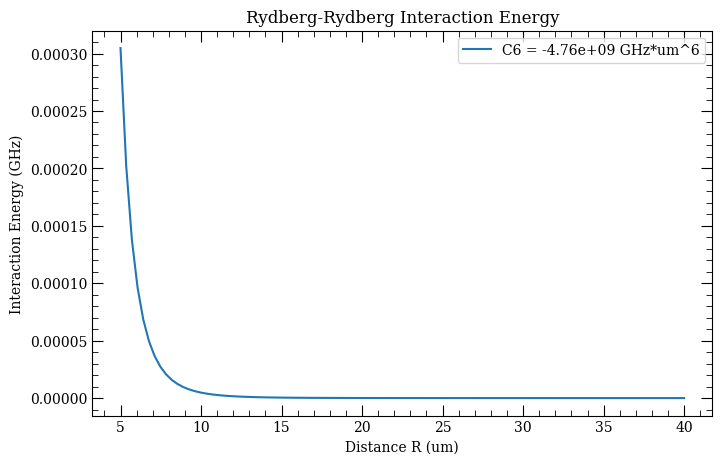

In [30]:
# Initialize the atom object from ARC
atom = arc.Rubidium85()
n,l,j,mj= 54, 1, 1.5,1.5
# Define the state
calc = arc.PairStateInteractions(
    atom,
    n, l, j,
    n, l, j,
    mj, mj
)
# Calculate C6
C6 = calc.getC6perturbatively(
    theta=0,
    phi=0,
    nRange=5,
    energyDelta=25*1e9,
    degeneratePerturbation=False
) * 10**9  # Convert from GHz to Hz
# Calculate Energy at R
def interaction_energy(R, C6):
    """Calculate the interaction energy at distance R given C6."""
    return np.abs(C6) / R**6
# Plotting
plt.figure(figsize=(8, 5))
R_values = np.linspace(5, 40, 100)  # Distance in micrometers
energies = interaction_energy(R_values, C6)
plt.plot(R_values, energies*10**-9, label=f'C6 = {C6:.2e} GHz*um^6')
plt.xlabel('Distance R (um)')
plt.ylabel('Interaction Energy (GHz)')
plt.title('Rydberg-Rydberg Interaction Energy')
plt.legend()
plt.show()


In [29]:
print(f"{interaction_energy(10, C6)*10**-3:.2e} kHz")  # Interaction energy at 10 micrometers

4.76e+00 kHz


In [12]:
def make_states(n):
    lower_state = (n,1,1.5,1.5)
    upper_state = (n+1,0,0.5,0.5)
    return lower_state, upper_state
def calculate_transition_energy(n):
    lower_state, upper_state = make_states(n)
    # Calculate the energy difference between the two states
    atom = arc.Rubidium85()
    return atom.getTransitionFrequency(lower_state[0], lower_state[1], lower_state[2],
                                    upper_state[0], upper_state[1], upper_state[2]) * 1e-9 # Convert to GHz
def calculate_c6(n):
    lower_state, upper_state = make_states(n)
    atom = arc.Rubidium85()
    calc = arc.PairStateInteractions(
        atom,
        lower_state[0], lower_state[1], lower_state[2],
        lower_state[0], lower_state[1], lower_state[2],
        lower_state[3], lower_state[3]
    )
    C6 = calc.getC6perturbatively(
        theta=0,
        phi=0,
        nRange=5,
        energyDelta=25*1e9,
        degeneratePerturbation=False
    ) * 10**9  # Convert from GHz to Hz
    return C6
def calculate_interaction_energy(R, n):
    C6 = calculate_c6(n)
    return np.abs(C6) / R**6


In [15]:
n_values = np.arange(50, 60)  # Range of n values
transition_energies = [calculate_transition_energy(n) for n in n_values]
interaction_energies = [calculate_interaction_energy(10, n) for n in n_values]  # Interaction energy at 10 micrometers

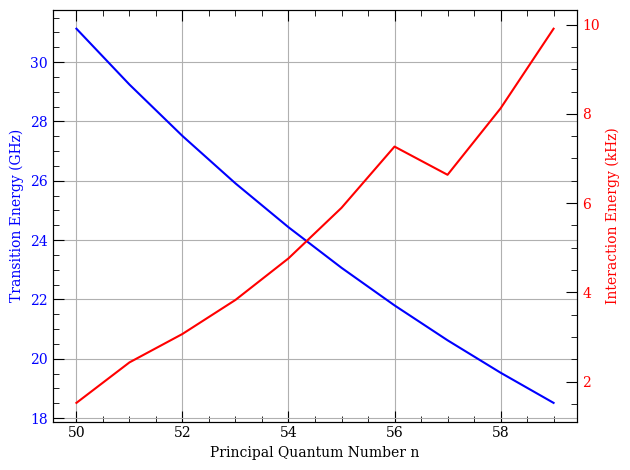

In [16]:
# plot with transition of left y and interaction on right y
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(n_values, transition_energies, 'b-', label='Transition Energy')
ax2.plot(n_values, np.array(interaction_energies)*10**-3, 'r-', label='Interaction Energy at 10 um')  # Convert to kHz
ax1.set_xlabel('Principal Quantum Number n')
ax1.set_ylabel('Transition Energy (GHz)', color='b')
ax2.set_ylabel('Interaction Energy (kHz)', color='r')
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')
ax1.grid()
fig.tight_layout()
plt.show()

In [21]:
# Scheme that is actually correct
atom = arc.Rubidium85()
ground_state = (5, 0, 0.5, 0.5)
e_state = (5, 1, 1.5, 1.5)
f_state = (54, 1, 1.5, 0.5)
r_state = (55, 0, 0.5, 0.5)

d_opt1 = atom.getDipoleMatrixElement(*ground_state, *e_state, 1)
d_blue1 = atom.getDipoleMatrixElement(*e_state, *r_state, -1)
d_UV1 = atom.getDipoleMatrixElement(*ground_state, *f_state, 0)
d_mm1 = atom.getDipoleMatrixElement(*f_state, *r_state, 0)
print(f"Optical dipole matrix element: {d_opt1:.6e} a.u.")
print(f"Blue dipole matrix element: {d_blue1:.6e} a.u.")
print(f"UV dipole matrix element: {d_UV1:.6e} a.u.")
print(f"Microwave dipole matrix element: {d_mm1:.6e} a.u.")

freq_mm1 = atom.getTransitionFrequency(*f_state[:3], *r_state[:3]) * 1e-9  # Convert to GHz
print(f"Microwave transition frequency: {freq_mm1:.6e} GHz")

Optical dipole matrix element: 2.989150e+00 a.u.
Blue dipole matrix element: -6.938086e-03 a.u.
UV dipole matrix element: -1.394265e-03 a.u.
Microwave dipole matrix element: 1.357770e+03 a.u.
Microwave transition frequency: 2.443221e+01 GHz


In [22]:
# Scheme that is currently (01July2026) in transducer calc
atom = arc.Rubidium85()
ground_state = (5, 0, 0.5, 0.5)
e_state = (5, 1, 1.5, 1.5)
f_state = (54, 1, 1.5, 1.5)
r_state = (55, 0, 0.5, 0.5)

d_opt2 = atom.getDipoleMatrixElement(*ground_state, *e_state, 1)
d_blue2 = atom.getDipoleMatrixElement(*e_state, *r_state, -1)
d_UV2 = atom.getDipoleMatrixElement(*ground_state, *f_state, 1)
d_mm2 = atom.getDipoleMatrixElement(*f_state, *r_state, -1)

print(f"Optical dipole matrix element: {d_opt2:.6e} a.u.")
print(f"Blue dipole matrix element: {d_blue2:.6e} a.u.")
print(f"UV dipole matrix element: {d_UV2:.6e} a.u.")
print(f"Microwave dipole matrix element: {d_mm2:.6e} a.u.")


Optical dipole matrix element: 2.989150e+00 a.u.
Blue dipole matrix element: -6.938086e-03 a.u.
UV dipole matrix element: 1.707619e-03 a.u.
Microwave dipole matrix element: 1.662921e+03 a.u.


In [17]:
# Scheme that is in Kumar2023
atom = arc.Rubidium85()
f_state = (35, 1, 0.5, -0.5)
r_state = (36, 0, 0.5, 0.5)

d_mm3 = atom.getDipoleMatrixElement(*f_state, *r_state, 1)
print(f"Microwave dipole matrix element: {d_mm3:.6e} a.u.")

Microwave dipole matrix element: -5.291890e+02 a.u.


In [25]:
d_mm1 / d_mm2

np.float64(0.816496580927726)